In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install unidecode

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import re

In [6]:
df = pd.read_csv("./data_all.csv")

In [7]:
df.isnull().sum()

Unnamed: 0                         0
id                                 0
career                             0
total_students                     0
new_graduates_number               0
public_cost                        0
private_cost                       0
public_quality_rating              0
private_quality_rating             0
occupation_rate                    4
unemployment_rate                  4
informality_rate                   0
quality_employment_probability    10
average_salary                     0
career_rank                       22
women_salary                       0
men_salary                         0
under_30_salary                    0
over_30_salary                     0
formal_salary                      0
informal_salary                    0
postgrad_percentage               17
postgrad_salary                    0
salary_increase                   39
dtype: int64

In [8]:
df.dtypes

Unnamed: 0                          int64
id                                  int64
career                             object
total_students                      int64
new_graduates_number                int64
public_cost                       float64
private_cost                      float64
public_quality_rating              object
private_quality_rating             object
occupation_rate                   float64
unemployment_rate                 float64
informality_rate                  float64
quality_employment_probability    float64
average_salary                    float64
career_rank                       float64
women_salary                      float64
men_salary                        float64
under_30_salary                   float64
over_30_salary                    float64
formal_salary                     float64
informal_salary                   float64
postgrad_percentage               float64
postgrad_salary                   float64
salary_increase                   

In [9]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [10]:
def fix_number(x):
    x = str(x)
    if "-" == x:
        return 0
    if "M" in x:
        print("Millón")
        x = float(x.replace('M',''))
        x = x * 1000000
        return int(x)
    if x.endswith(".0"):
        parts = x.split('.')
        print(parts[0], flush=True)
        return int(parts[0])
    else:
        return int(float(x.replace('.', '')))

In [11]:
df['new_graduates_number'] = df['new_graduates_number'].apply(fix_number)

In [12]:
df.head()

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30


In [13]:
df['total_students'] = df['total_students'].apply(fix_number)

In [14]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [15]:
def remove_money_simbol(x):
    if "$" in x:
        x = x.replace('$','')
        return x
    if "-" == x:
        return 0

In [16]:
cols_with_dollar = df.columns[df.astype(str).apply(lambda col: col.str.contains('\$').any())]

In [17]:
cols_with_dollar

Index([], dtype='object')

In [18]:
for col in cols_with_dollar:
    df[col] = df[col].apply(remove_money_simbol)
    df[col] = df[col].apply(fix_number)

In [19]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,NaN,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [20]:
def remove_rank_signal(x):
    x = str(x).strip()  
    
    if "°" in x:
        x = x.replace('°', '').strip()
        if x == "-" or x == "": 
            return None
        return int(x)
    
    return x

In [21]:
df['career_rank'] = df['career_rank'].apply(remove_rank_signal)

In [22]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [23]:
def remove_percentage_signal(x):
    x = str(x).strip()  
    
    if "%" in x:
        x = x.replace('%', '').strip()
        if x == "-" or x == "": 
            return np.nan
        return float(x)
    
    return x

In [24]:
df['postgrad_percentage'] = df['postgrad_percentage'].apply(remove_percentage_signal)

In [25]:
def remove_(x):
    if "-" == x:
        return np.nan
    else: 
        return x

In [26]:
df['postgrad_percentage'] = df['postgrad_percentage'].apply(remove_)

In [27]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [28]:
def clean_percentage(x):
    x = str(x).strip()          
    x = x.replace('%', '')       
    x = x.replace(',', '.')      
    try:
        return float(x)
    except ValueError:
        return np.nan            

In [29]:
df['salary_increase'] = df['salary_increase'].apply(clean_percentage)
df['occupation_rate'] = df['occupation_rate'].apply(clean_percentage)
df['unemployment_rate'] = df['unemployment_rate'].apply(clean_percentage)
df['informality_rate'] = df['informality_rate'].apply(clean_percentage)
df['quality_employment_probability'] = df['quality_employment_probability'].apply(clean_percentage)

In [30]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [31]:
cols_with_dollar

Index([], dtype='object')

In [32]:
def remove_zeros(x, mean_value):
    return mean_value if x == 0 else x

for col in cols_with_dollar:
    mean_value = df[col][df[col] != 0].mean()
    df[col] = df[col].apply(lambda x: remove_zeros(x, round(mean_value,2)))


In [33]:
df

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


In [34]:
df.describe()

,Unnamed: 0,id,total_students,new_graduates_number,public_cost,private_cost,occupation_rate,unemployment_rate,informality_rate,quality_employment_probability,average_salary,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_salary,salary_increase
count,81.000000,81.000000,8.100000e+01,81.000000,81.000000,8.100000e+01,77.000000,77.000000,81.000000,71.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,42.000000
mean,40.000000,40.000000,2.227476e+05,8795.037037,42359.698765,2.755122e+05,96.466234,3.541558,29.333333,74.556338,19832.711358,18455.859753,21249.228642,16354.339259,20990.761975,21541.848148,13974.017778,34389.309753,194.052143
std,23.526581,23.526581,2.750472e+05,12173.469877,9156.404714,1.724113e+05,1.828690,1.825575,12.166347,7.848780,4551.453166,4047.690982,4832.172974,3284.042987,4918.939000,4686.748667,2673.869871,6252.781390,32.972386
min,0.000000,0.000000,2.111700e+04,0.000000,23152.000000,3.629100e+04,89.700000,0.100000,8.600000,51.300000,10130.000000,10325.000000,5520.000000,10338.000000,9732.000000,11301.000000,8626.000000,16390.000000,75.560000
25%,20.000000,20.000000,6.420200e+04,1459.000000,40978.000000,1.762090e+05,95.700000,2.300000,21.300000,70.750000,17384.000000,16651.000000,19174.000000,14384.000000,18901.000000,19292.000000,12355.000000,32187.000000,177.017500
50%,40.000000,40.000000,1.098960e+05,4347.000000,42359.700000,2.755122e+05,96.600000,3.400000,26.100000,74.600000,19832.710000,18455.860000,21249.230000,16354.340000,20990.760000,21541.850000,13974.020000,34389.310000,195.815000
75%,60.000000,60.000000,2.518240e+05,10476.000000,46870.000000,2.755122e+05,97.700000,4.300000,36.500000,80.550000,22021.000000,19942.000000,23349.000000,17393.000000,23412.000000,23525.000000,15000.000000,34421.000000,216.765000
max,80.000000,80.000000,1.300000e+06,70987.000000,70605.000000,1.200000e+06,99.900000,10.300000,77.500000,90.300000,43587.000000,38077.000000,46811.000000,28167.000000,44690.000000,45034.000000,24471.000000,56013.000000,247.520000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      81 non-null     int64  
 1   id                              81 non-null     int64  
 2   career                          81 non-null     object 
 3   total_students                  81 non-null     int64  
 4   new_graduates_number            81 non-null     int64  
 5   public_cost                     81 non-null     float64
 6   private_cost                    81 non-null     float64
 7   public_quality_rating           81 non-null     object 
 8   private_quality_rating          81 non-null     object 
 9   occupation_rate                 77 non-null     float64
 10  unemployment_rate               77 non-null     float64
 11  informality_rate                81 non-null     float64
 12  quality_employment_probability  71 non

In [36]:
import matplotlib.pyplot as plt

In [37]:
df_unique = df.drop_duplicates(subset='career')

In [38]:
df_unique

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,18.0,19561.00,25207.00,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,32.0,16651.00,20528.00,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,40.0,16595.00,19242.00,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,43.0,16935.00,17447.00,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,nan,18455.86,21249.23,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN


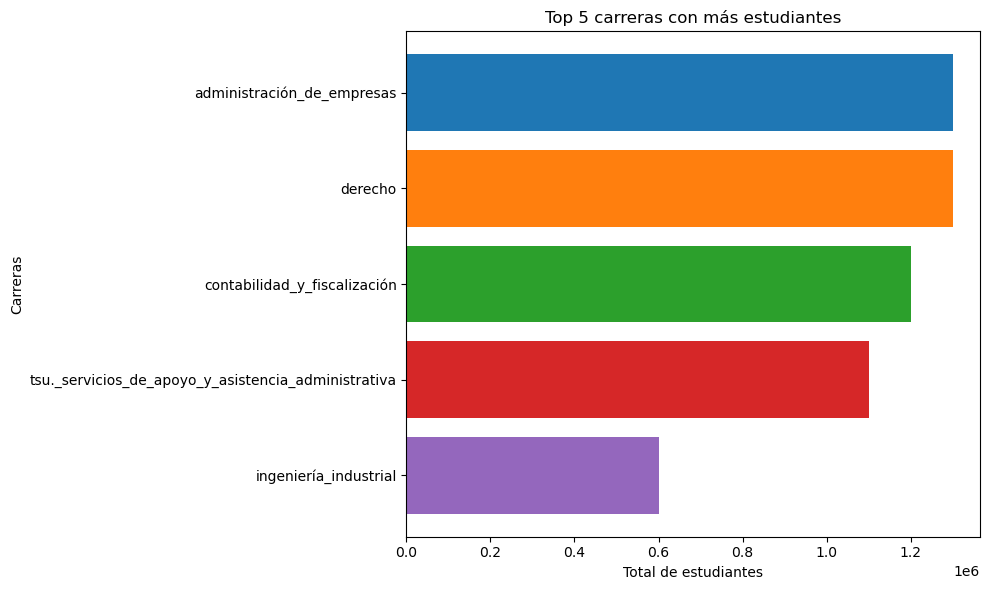

<Figure size 640x480 with 0 Axes>

In [39]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='total_students', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['total_students'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más estudiantes')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()
plt.savefig("top5_masestudiantes.png")

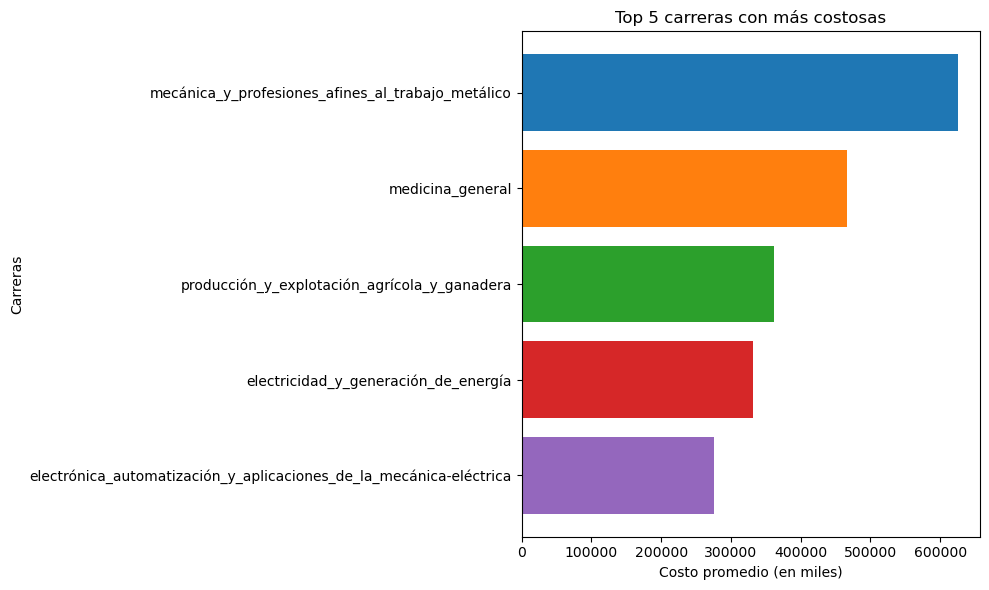

<Figure size 640x480 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
df_unique['avg_cost'] = (df_unique['private_cost'] + df_unique['public_cost']) / 2
# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='avg_cost', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['avg_cost'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Costo promedio (en miles)')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más costosas')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()
plt.savefig("top5_costosas.png")

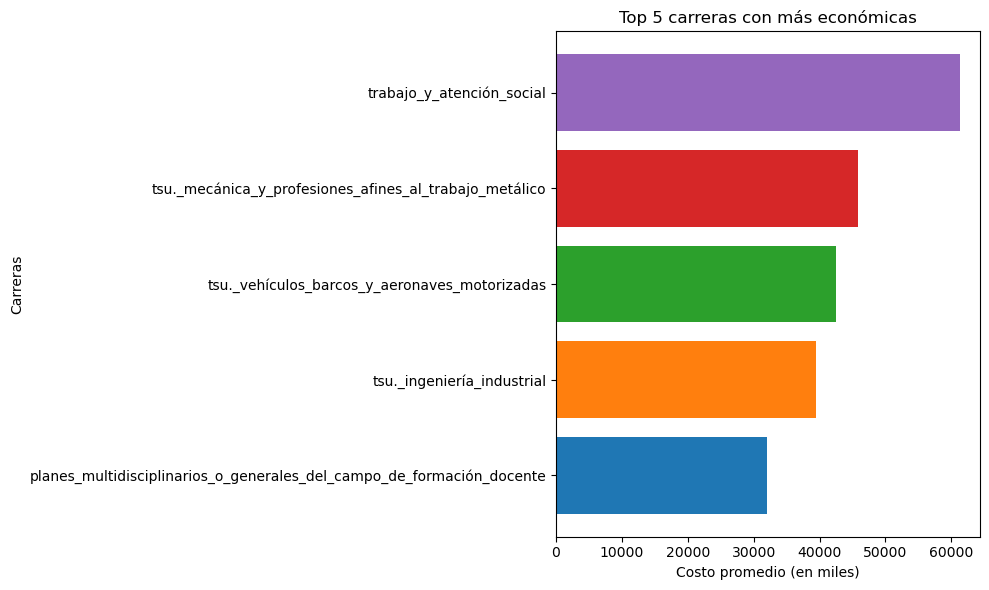

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='avg_cost', ascending=True).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['avg_cost'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Costo promedio (en miles)')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más económicas')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()
plt.savefig("top5_economicas.png")

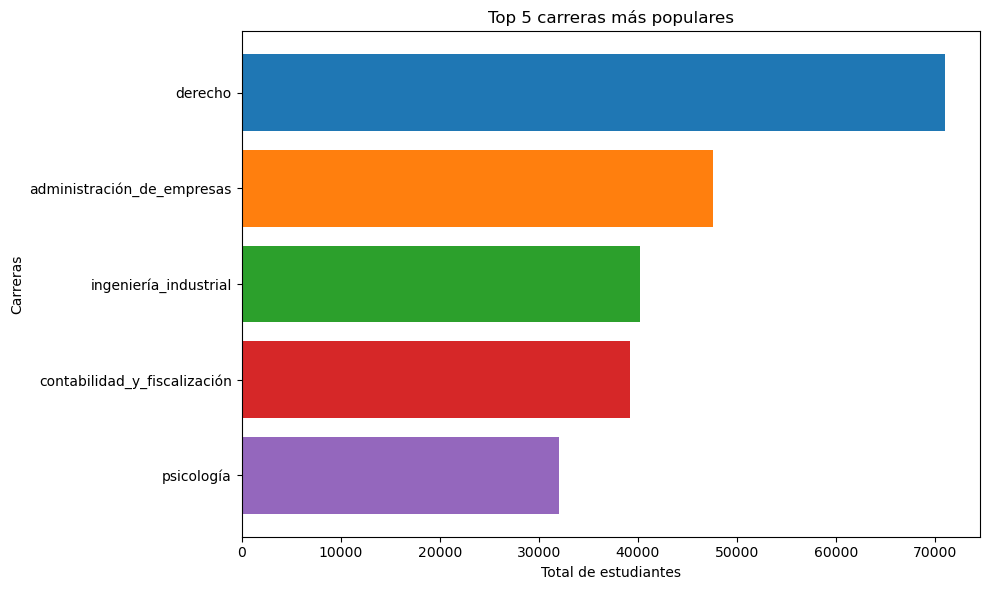

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='new_graduates_number', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['new_graduates_number'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras más populares')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()
plt.savefig("top5_populares.png")

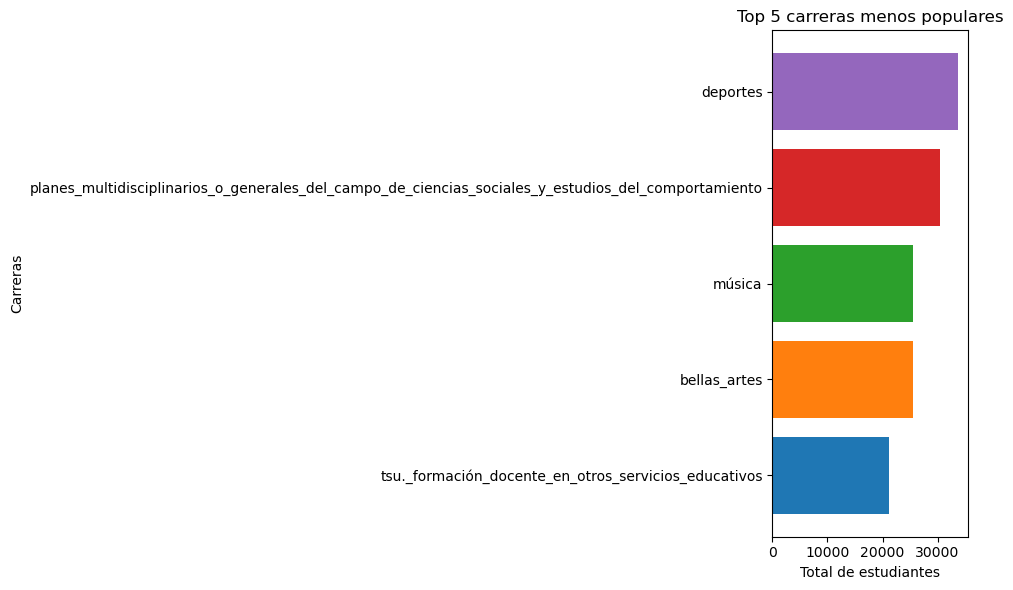

<Figure size 640x480 with 0 Axes>

In [43]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='total_students', ascending=True).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['total_students'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras menos populares')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()
plt.savefig("top5_menospopulares.png")

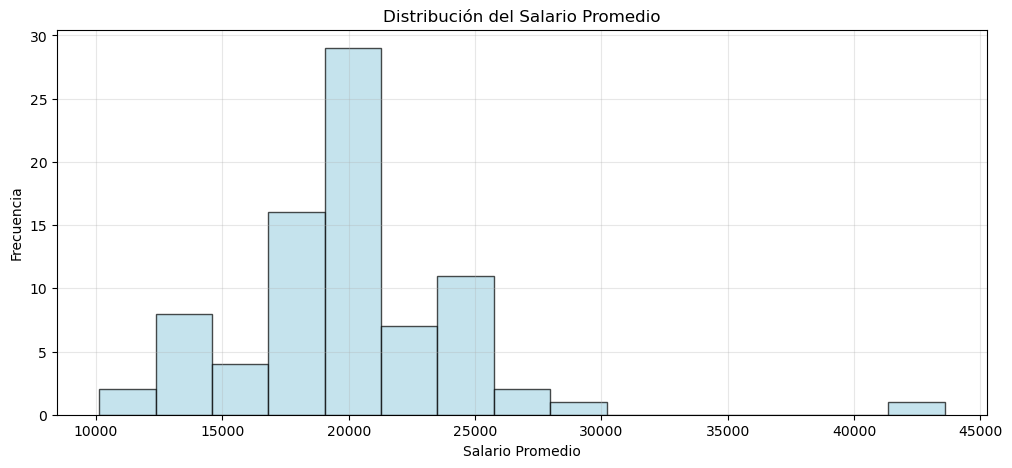

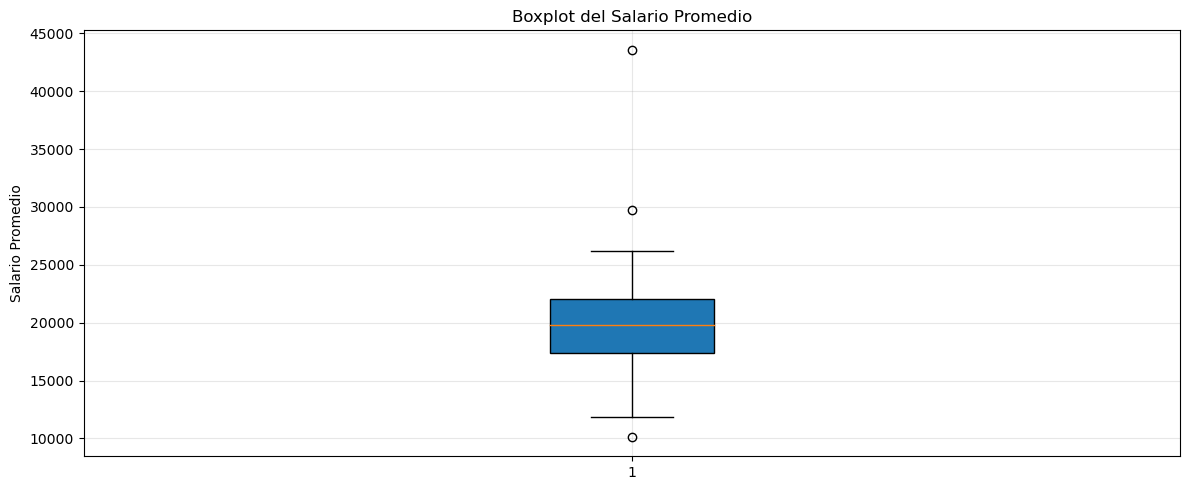

Estadísticas del Salario Promedio:
Media: 19832.71
Mediana: 19832.71
Desviación estándar: 4551.45


<Figure size 640x480 with 0 Axes>

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Gráfica de distribución del salario promedio
plt.figure(figsize=(12, 5))

# Histograma
plt.hist(df_unique['average_salary'], bins=15, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('Salario Promedio')
plt.ylabel('Frecuencia')
plt.title('Distribución del Salario Promedio')
plt.grid(True, alpha=0.3)
plt.show()
# Boxplot
plt.figure(figsize=(12, 5))
plt.boxplot(df_unique['average_salary'], vert=True, patch_artist=True)
plt.ylabel('Salario Promedio')
plt.title('Boxplot del Salario Promedio')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("Distribucion.png")

# Estadísticas descriptivas
print("Estadísticas del Salario Promedio:")
print(f"Media: {df_unique['average_salary'].mean():.2f}")
print(f"Mediana: {df_unique['average_salary'].median():.2f}")
print(f"Desviación estándar: {df_unique['average_salary'].std():.2f}")


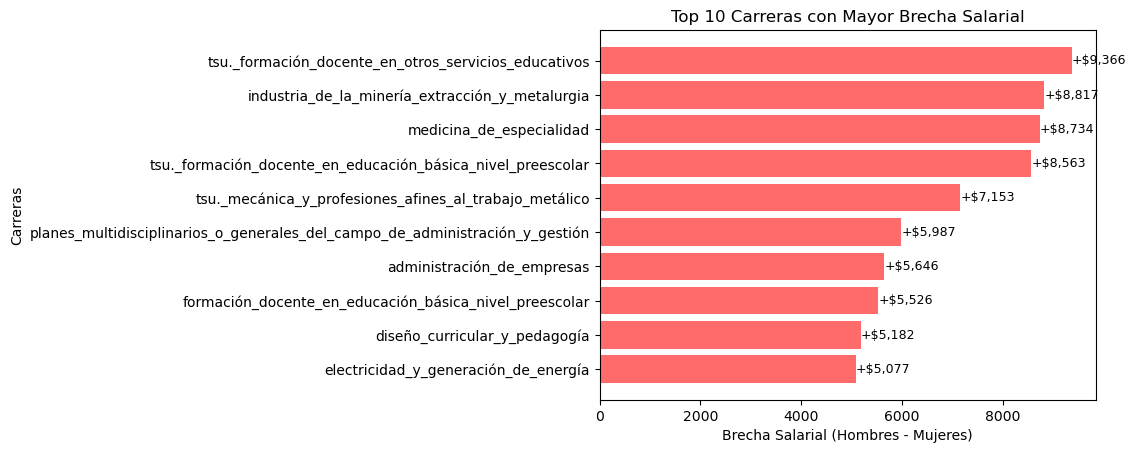

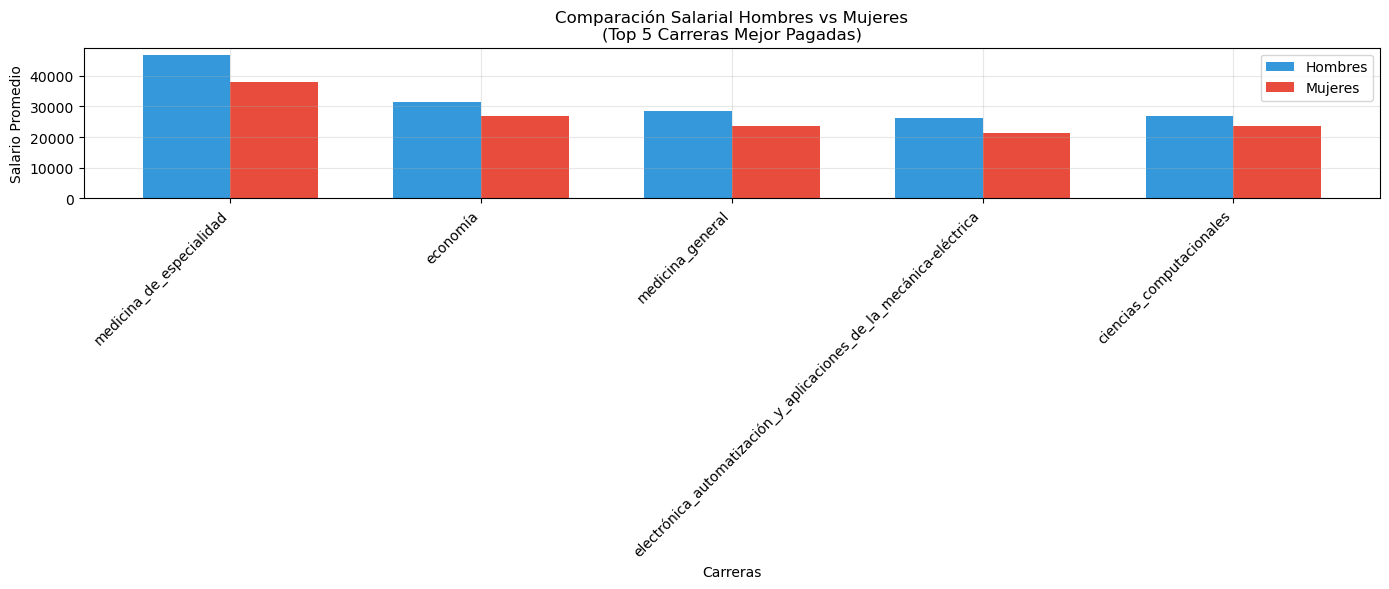


Estadísticas de Brecha Salarial:
Brecha salarial promedio: $2793.37
Brecha porcentual promedio: 15.86%
Carreras con brecha a favor de hombres: 74
Carreras con brecha a favor de mujeres: 7


In [45]:
# Gráfica de brecha salarial
# Subgráfica 1: Comparación directa

# Calcular brecha salarial
df_unique['salary_gap'] = df_unique['men_salary'] - df_unique['women_salary']
df_unique['gap_percentage'] = (df_unique['salary_gap'] / df_unique['women_salary']) * 100

# Top 10 carreras con mayor brecha salarial
df_gap_top10 = df_unique.nlargest(10, 'salary_gap')

bars = plt.barh(df_gap_top10['career'], df_gap_top10['salary_gap'], 
                color=['#ff6b6b' if x > 0 else '#4ecdc4' for x in df_gap_top10['salary_gap']])
plt.xlabel('Brecha Salarial (Hombres - Mujeres)')
plt.ylabel('Carreras')
plt.title('Top 10 Carreras con Mayor Brecha Salarial')
plt.gca().invert_yaxis()

# Agregar valores
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'+${int(width):,}', 
             ha='left' if width > 0 else 'right', 
             va='center', fontsize=9)
plt.show()
# Subgráfica 2: Comparación hombres vs mujeres
plt.figure(figsize=(14, 6))
# Top 5 carreras para comparación
df_comparison = df_unique.nlargest(5, 'average_salary')

x = np.arange(len(df_comparison))
width = 0.35

plt.bar(x - width/2, df_comparison['men_salary'], width, label='Hombres', color='#3498db')
plt.bar(x + width/2, df_comparison['women_salary'], width, label='Mujeres', color='#e74c3c')

plt.xlabel('Carreras')
plt.ylabel('Salario Promedio')
plt.title('Comparación Salarial Hombres vs Mujeres\n(Top 5 Carreras Mejor Pagadas)')
plt.xticks(x, df_comparison['career'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de brecha salarial
print("\nEstadísticas de Brecha Salarial:")
print(f"Brecha salarial promedio: ${df_unique['salary_gap'].mean():.2f}")
print(f"Brecha porcentual promedio: {df_unique['gap_percentage'].mean():.2f}%")
print(f"Carreras con brecha a favor de hombres: {(df_unique['salary_gap'] > 0).sum()}")
print(f"Carreras con brecha a favor de mujeres: {(df_unique['salary_gap'] < 0).sum()}")

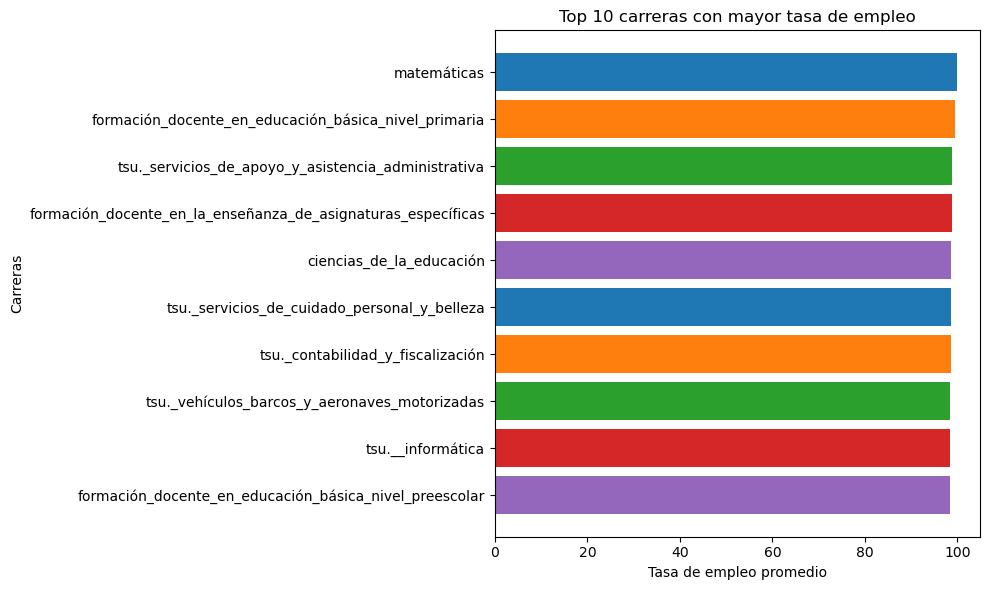

In [46]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='occupation_rate', ascending=False).head(10)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['occupation_rate'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Tasa de empleo promedio')
plt.ylabel('Carreras')
plt.title('Top 10 carreras con mayor tasa de empleo')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

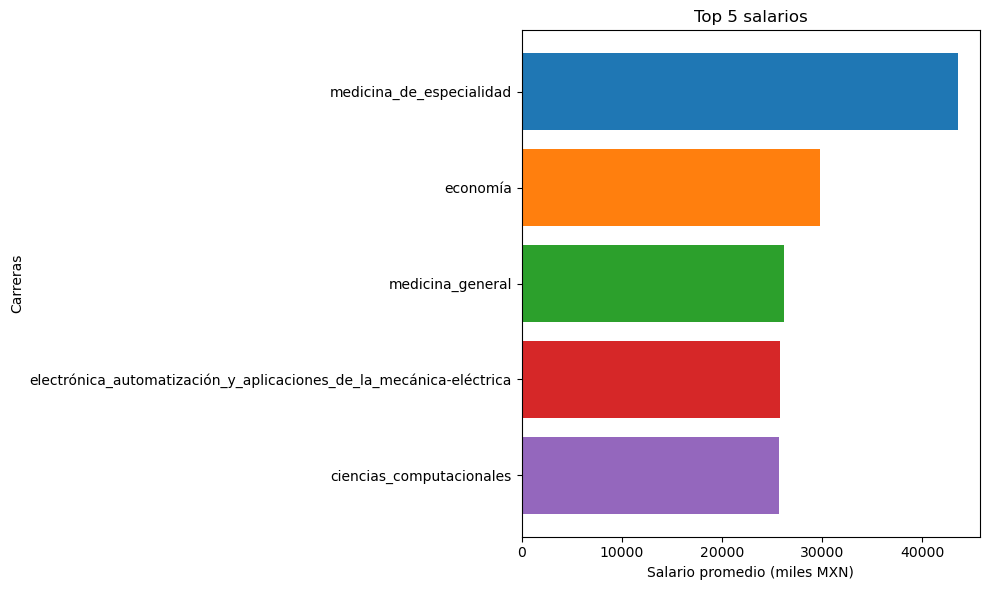

In [47]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='average_salary', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['average_salary'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Salario promedio (miles MXN)')
plt.ylabel('Carreras')
plt.title('Top 5 salarios')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [48]:
df_unique

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase,avg_cost,salary_gap,gap_percentage
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71,139456.00,5646.00,28.863555
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN,158935.96,2793.37,15.135410
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN,158935.96,2793.37,15.135410
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49,247906.00,3877.00,23.283887
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30,108832.00,2647.00,15.950588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN,158935.96,2793.37,15.135410
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN,158935.96,2793.37,15.135410
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47,61290.00,512.00,3.023324
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN,158935.96,2793.37,15.135410


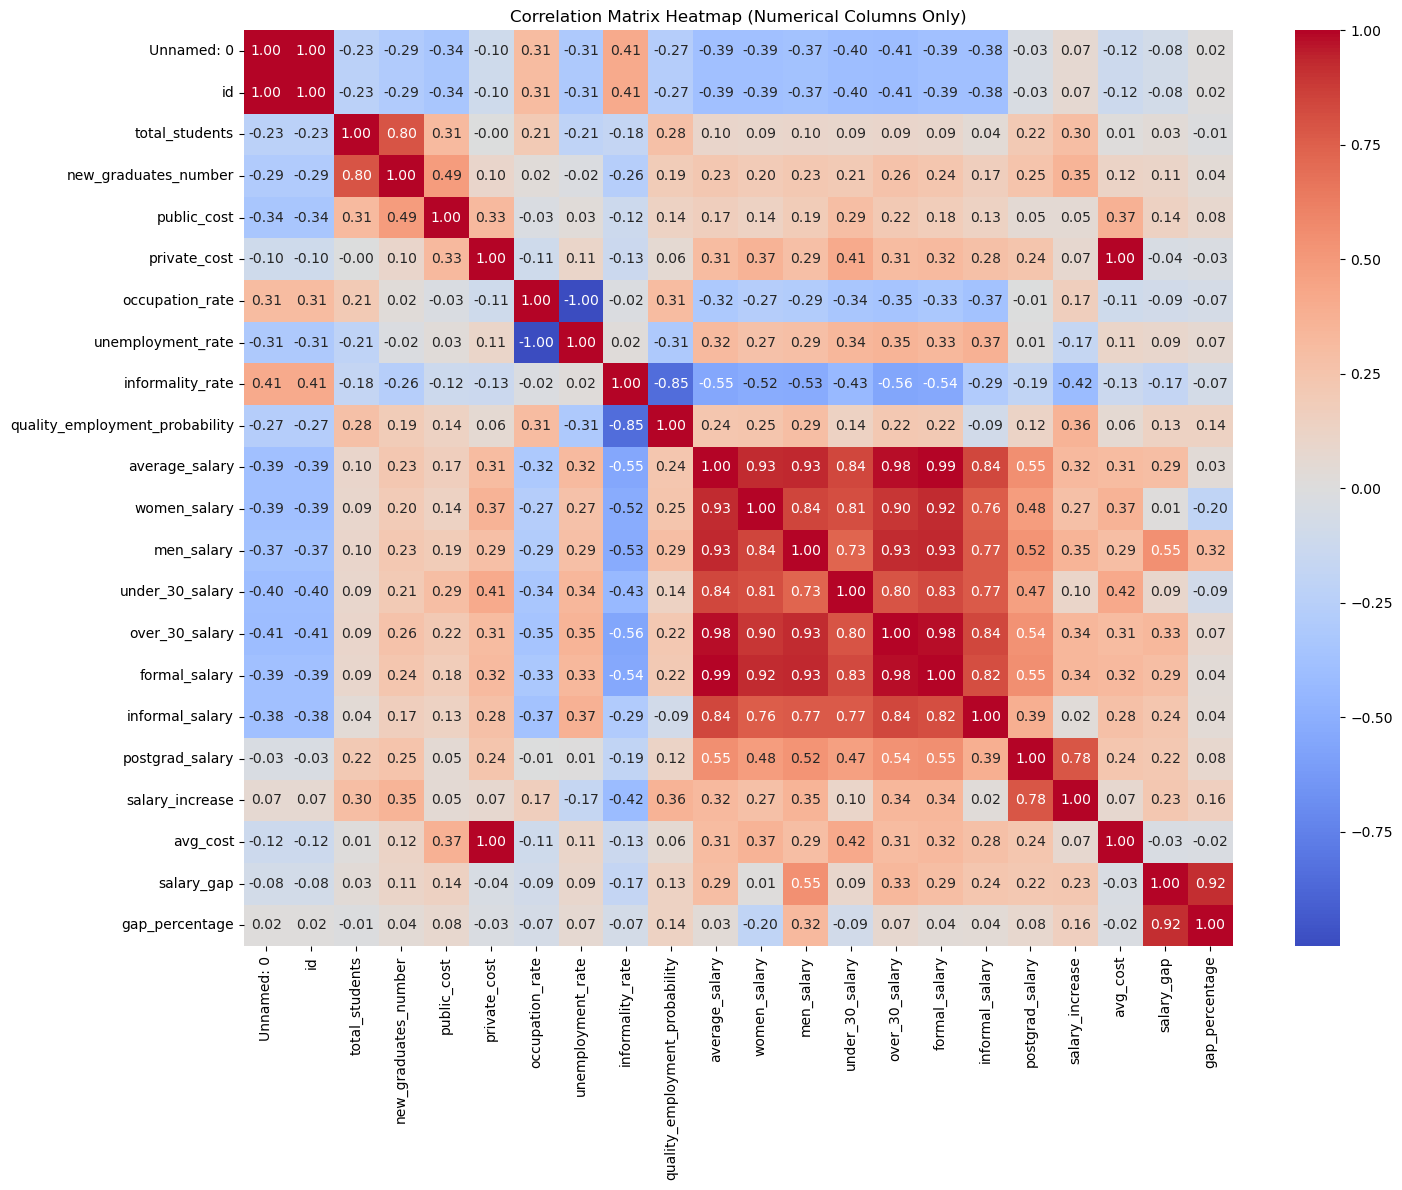

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate correlation matrix only for numerical columns
numerical_df = df_unique.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap (Numerical Columns Only)')
plt.tight_layout()
plt.show()

In [50]:
df_unique

,Unnamed: 0,id,career,total_students,new_graduates_number,public_cost,private_cost,public_quality_rating,private_quality_rating,occupation_rate,...,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase,avg_cost,salary_gap,gap_percentage
0,0,0,administración_de_empresas,1300000,47537,50156.0,228756.00,Buena,Buena,96.8,...,16723.00,24358.00,23740.00,16242.00,8.5,43317.00,236.71,139456.00,5646.00,28.863555
1,1,1,administración_en_el_ámbito_de_la_ingeniería_y...,79106,3539,42359.7,275512.22,-,-,94.7,...,16354.34,20990.76,21541.85,13974.02,6.0,34389.31,NaN,158935.96,2793.37,15.135410
2,2,2,administración_pública,48254,1938,42359.7,275512.22,-,-,98.1,...,16354.34,20990.76,21541.85,13974.02,49.6,34389.31,NaN,158935.96,2793.37,15.135410
3,3,3,administración_turística_y_de_restaurantes,61850,6029,44415.0,451397.00,Insegura,Muy Insegura,93.9,...,14702.00,19567.00,19757.00,12040.00,7.4,26889.00,174.49,247906.00,3877.00,23.283887
4,4,4,adquisición_de_idiomas_extranjeros,77839,3083,47970.0,169694.00,Muy Insegura,Muy Insegura,94.1,...,14089.00,19676.00,18491.00,13691.00,3.0,27178.00,181.30,108832.00,2647.00,15.950588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,76,tecnología_para_la_protección_del_medio_ambiente,34168,3287,42359.7,275512.22,-,-,94.2,...,16354.34,20990.76,21541.85,13974.02,8.5,34389.31,NaN,158935.96,2793.37,15.135410
77,77,77,terapia_y_rehabilitación,66243,8890,42359.7,275512.22,-,-,96.8,...,16354.34,20990.76,21541.85,13974.02,3.7,34389.31,NaN,158935.96,2793.37,15.135410
78,78,78,trabajo_y_atención_social,157770,7898,33790.0,88790.00,Buena,Excelente,97.2,...,13446.00,18335.00,18159.00,12450.00,3.6,27548.00,188.47,61290.00,512.00,3.023324
79,79,79,vehículos_barcos_y_aeronaves_motorizadas,71470,6150,42359.7,275512.22,-,-,97.3,...,16354.34,20990.76,21541.85,13974.02,1.2,34389.31,NaN,158935.96,2793.37,15.135410


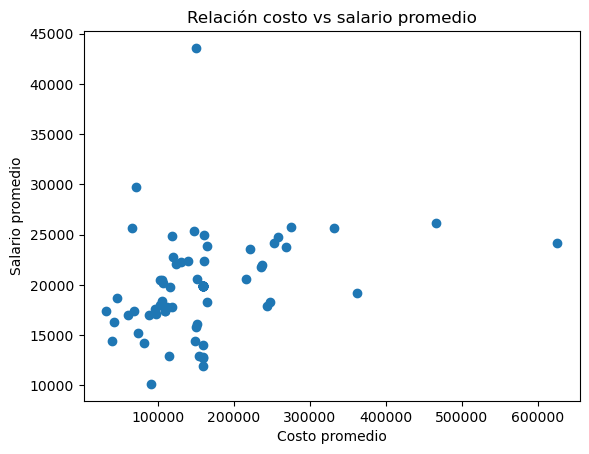

In [51]:
plt.scatter(df_unique['avg_cost'], df_unique['average_salary'])

# Add labels and title for clarity
plt.xlabel("Costo promedio")
plt.ylabel("Salario promedio")
plt.title("Relación costo vs salario promedio")

# Display the plot
plt.show()

In [52]:
import plotly.express as px

fig = px.scatter(df_unique, 
                 x='avg_cost', 
                 y='average_salary', 
                 hover_data=['career'],  # muestra la carrera al hacer hover
                 title="Relación costo vs salario promedio")
fig.show()

C:\Users\luisn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\luisn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



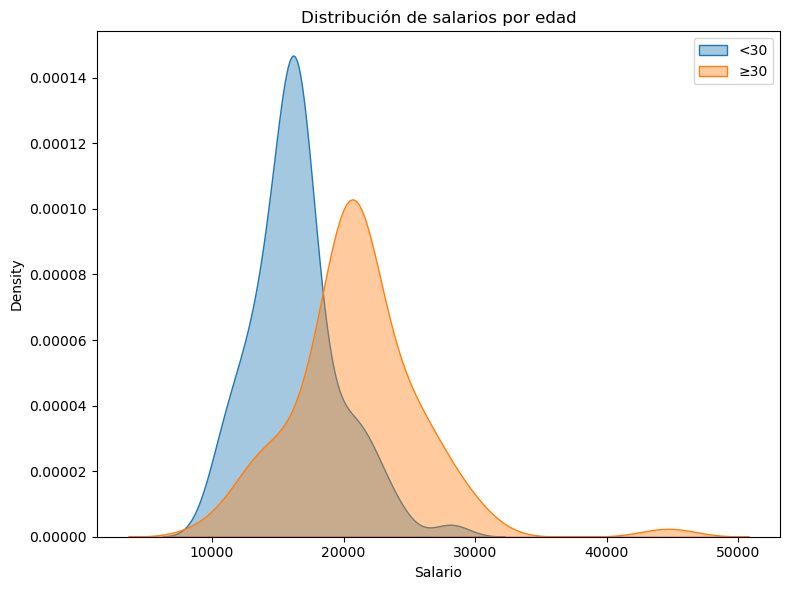

In [53]:
plt.figure(figsize=(8,6))
sns.kdeplot(df['under_30_salary'].dropna(), label='<30', fill=True, alpha=0.4)
sns.kdeplot(df['over_30_salary'].dropna(), label='≥30', fill=True, alpha=0.4)
plt.title("Distribución de salarios por edad"); 
plt.xlabel("Salario"); 
plt.legend(); 
plt.tight_layout(); 
plt.show()

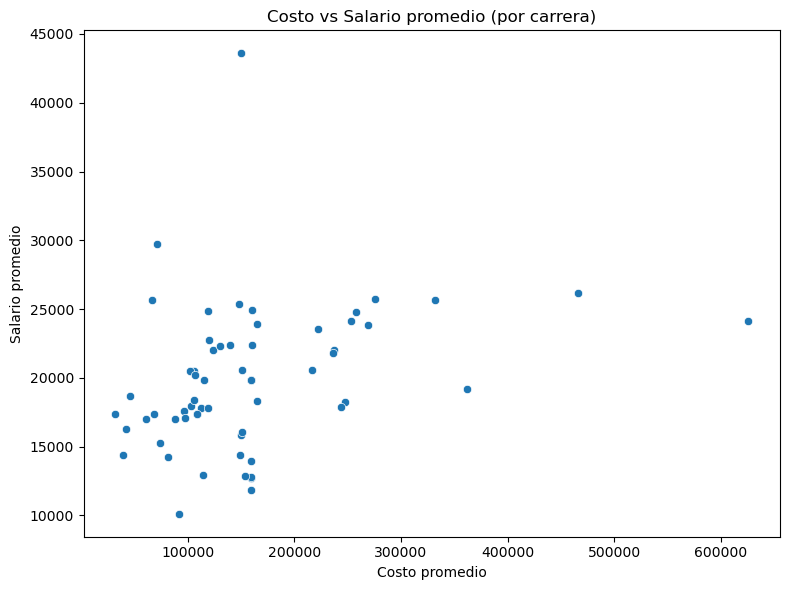

In [54]:
agg = df_unique.groupby('career')[['avg_cost', 'average_salary']].mean().dropna()
plt.figure(figsize=(8,6))
sns.scatterplot(data=agg, x='avg_cost', y='average_salary')
plt.title("Costo vs Salario promedio (por carrera)"); plt.xlabel("Costo promedio"); plt.ylabel("Salario promedio")
plt.tight_layout(); plt.show()

In [55]:
df_unique.columns

Index(['Unnamed: 0', 'id', 'career', 'total_students', 'new_graduates_number',
       'public_cost', 'private_cost', 'public_quality_rating',
       'private_quality_rating', 'occupation_rate', 'unemployment_rate',
       'informality_rate', 'quality_employment_probability', 'average_salary',
       'career_rank', 'women_salary', 'men_salary', 'under_30_salary',
       'over_30_salary', 'formal_salary', 'informal_salary',
       'postgrad_percentage', 'postgrad_salary', 'salary_increase', 'avg_cost',
       'salary_gap', 'gap_percentage'],
      dtype='object')

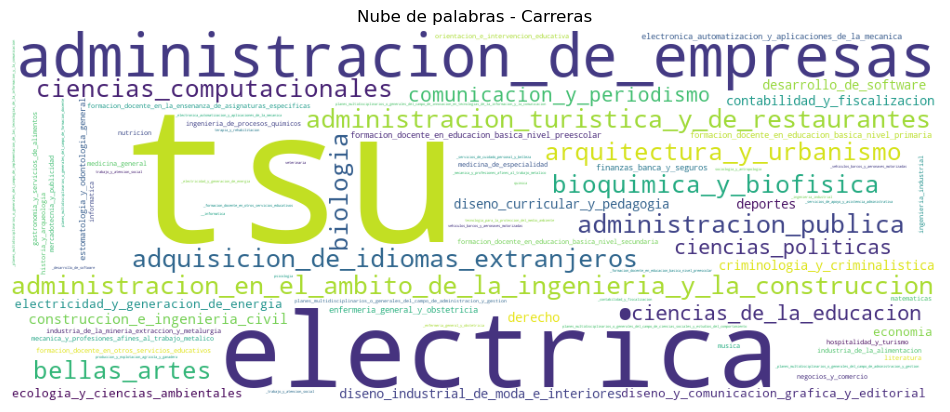

In [58]:
from unidecode import unidecode
from wordcloud import WordCloud
text = " ".join(df['career'].dropna().astype(str).tolist())
text = unidecode(text.lower())
wc = WordCloud(width=1000, height=400, background_color="white").generate(text)
plt.figure(figsize=(12,5)); plt.imshow(wc); plt.axis("off"); plt.title("Nube de palabras - Carreras"); plt.show()